In [ ]:
import requests
import os

url = "https://www.gutenberg.org/cache/epub/100/pg100.txt"
response = requests.get(url)
text = response.text

with open("input.txt", "w", encoding="utf-8") as f:
    f.write(text)


Raw text length (characters): 5575062
✅ Saved full Shakespeare to input.txt
No existing shakespeare-bpe.json found; tokenizer will be trained fresh.


In [13]:
!python -m pip install tokenizers matplotlib
import os, random, unicodedata, json
from collections import Counter
import numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

SEED = 1337
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


In [14]:
CONFIG = {
    'vocab_size': 3000,
    'block_size': 256,
    'batch_size': 64,
    'n_embd': 384,
    'n_head': 6,
    'n_layer': 6,
    'dropout': 0.2,
    'learning_rate': 3e-4,
    'max_iters': 5000,
    'eval_interval': 500,
    'eval_iters': 200,
    'split_ratio': 0.9,
    'warmup_steps': 1000,
    'final_lr_scale': 0.05,
    'weight_decay': 0.1,
    'grad_clip': 1.0
}

In [15]:
def initialize_tokenizer():
    tokenizer_path = "shakespeare-bpe.json"

    if not os.path.exists(tokenizer_path):
        tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
        tokenizer.pre_tokenizer = Whitespace()

        trainer = BpeTrainer(
            vocab_size=CONFIG['vocab_size'],
            special_tokens=["[PAD]", "[UNK]", "[BOS]", "[EOS]"]
        )

        tokenizer.train(files=["input.txt"], trainer=trainer)
        tokenizer.save(tokenizer_path)
        return tokenizer
    else:
        tokenizer = Tokenizer.from_file(tokenizer_path)
        return tokenizer

def encode(text, tokenizer):
    return tokenizer.encode(text).ids

def decode(ids, tokenizer):
    return tokenizer.decode(ids)


In [16]:
def get_batch(split, data_splits, deterministic=False):
    data_split = data_splits['train'] if split == 'train' else data_splits['val']

    if deterministic:
        g = torch.Generator().manual_seed(42)
        ix = torch.randint(len(data_split) - CONFIG['block_size'], (CONFIG['batch_size'],), generator=g)
    else:
        ix = torch.randint(len(data_split) - CONFIG['block_size'], (CONFIG['batch_size'],))

    x = torch.stack([data_split[i:i+CONFIG['block_size']] for i in ix])
    y = torch.stack([data_split[i+1:i+CONFIG['block_size']+1] for i in ix])

    return (
        x.pin_memory().to(device, non_blocking=True),
        y.pin_memory().to(device, non_blocking=True)
    )

@torch.inference_mode()
def estimate_loss(model, data_splits):
    out = {}
    model.eval()

    for split in ['train', 'val']:
        losses = torch.zeros(CONFIG['eval_iters'])
        for k in range(CONFIG['eval_iters']):
            X, Y = get_batch(split, data_splits, deterministic=True)
            _, loss = model(X, Y)
            losses[k] = loss.item()

        mean_loss = losses.mean()
        out[split] = {
            "loss": mean_loss.item(),
            "ppl": torch.exp(mean_loss).item()
        }

    model.train()
    return out


In [17]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(CONFIG['n_embd'], head_size, bias=False)
        self.query = nn.Linear(CONFIG['n_embd'], head_size, bias=False)
        self.value = nn.Linear(CONFIG['n_embd'], head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(CONFIG['block_size'], CONFIG['block_size'])))
        self.dropout = nn.Dropout(CONFIG['dropout'])

    def forward(self, x):
        B, T, _ = x.shape
        k = self.key(x)  # (B, T, head_size)
        q = self.query(x)  # (B, T, head_size)

        # Scaled dot-product attention
        dk = q.size(-1)
        wei = (q @ k.transpose(-2, -1)) * (dk ** -0.5)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        # Value transformation and aggregation
        v = self.value(x)  # (B, T, head_size)
        return wei @ v  # (B, T, head_size)

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(CONFIG['n_embd'], CONFIG['n_embd'])
        self.dropout = nn.Dropout(CONFIG['dropout'])

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))

class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(CONFIG['dropout']),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))  # Residual connection + layer norm
        x = x + self.ffwd(self.ln2(x))  # Residual connection + layer norm
        return x

class GPTLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(CONFIG['vocab_size'], CONFIG['n_embd'])
        self.position_embedding_table = nn.Embedding(CONFIG['block_size'], CONFIG['n_embd'])
        self.blocks = nn.Sequential(*[Block(CONFIG['n_embd'], CONFIG['n_head']) for _ in range(CONFIG['n_layer'])])
        self.ln_f = nn.LayerNorm(CONFIG['n_embd'])
        self.lm_head = nn.Linear(CONFIG['n_embd'], CONFIG['vocab_size'])

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # Embed tokens and positions
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb

        # Forward through transformer blocks
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        # Calculate loss if targets provided
        if targets is None:
            return logits, None

        B, T, C = logits.shape
        logits = logits.view(B * T, C)
        targets = targets.view(B * T)
        loss = F.cross_entropy(logits, targets)
        return logits, loss

    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            # Crop context to block_size
            idx_cond = idx[:, -CONFIG['block_size']:]

            # Get predictions
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]  # Focus on last time step

            # Apply temperature
            logits = logits / temperature

            # Apply top-k filtering if specified
            if top_k is not None:
                v, _ = torch.topk(logits, top_k)
                logits[logits < v[:, [-1]]] = -float('Inf')

            # Sample next token
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)

        return idx

In [18]:
def get_lr(step):
    if step < CONFIG['warmup_steps']:
        return CONFIG['learning_rate'] * (step + 1) / CONFIG['warmup_steps']

    progress = (step - CONFIG['warmup_steps']) / max(1, (CONFIG['max_iters'] - CONFIG['warmup_steps']))
    return CONFIG['learning_rate'] * (CONFIG['final_lr_scale'] + 0.5 * (1 - CONFIG['final_lr_scale']) * (1 + np.cos(np.pi * progress)))

def safe_ppl(loss):
    try:
        return float(np.exp(min(50.0, float(loss))))
    except Exception:
        return float('inf')

In [19]:
def main():
    # Set device
    global device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Initialize tokenizer
    tokenizer = initialize_tokenizer()

    # Test encode/decode
    test_text = "To be or not to be"
    encoded = encode(test_text, tokenizer)
    decoded = decode(encoded, tokenizer)
    print(f"Sample encoding: {encoded}")
    print(f"Decoded back: {decoded}")

    # Load and encode dataset
    with open("input.txt", "r", encoding="utf-8") as f:
        text = f.read()

    data = torch.tensor(encode(text, tokenizer), dtype=torch.long)

    # Train/validation split
    n = int(CONFIG['split_ratio'] * len(data))
    data_splits = {
        'train': data[:n],
        'val': data[n:]
    }

    print(f"Train tokens: {len(data_splits['train'])}, Val tokens: {len(data_splits['val'])}")

    # Initialize model
    model = GPTLanguageModel().to(device)
    model.lm_head.weight = model.token_embedding_table.weight  # Weight tying

    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Model has {total_params/1e6:.2f}M parameters")

    # Initialize optimizer
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG['learning_rate'],
        weight_decay=CONFIG['weight_decay']
    )

    # Training tracking
    train_losses, val_losses, eval_steps = [], [], []

    # Training loop
    for iter in range(CONFIG['max_iters']):
        # Learning rate scheduling
        for param_group in optimizer.param_groups:
            param_group['lr'] = get_lr(iter)

        # Evaluation
        if iter % CONFIG['eval_interval'] == 0 or iter == CONFIG['max_iters'] - 1:
            losses = estimate_loss(model, data_splits)

            # Store for plotting
            train_losses.append(float(losses['train']['loss']))
            val_losses.append(float(losses['val']['loss']))
            eval_steps.append(int(iter))

            # Print progress
            t_loss, v_loss = losses['train']['loss'], losses['val']['loss']
            print(
                f"step {iter}: "
                f"train {t_loss:.4f} (ppl {safe_ppl(t_loss):.1f}), "
                f"val {v_loss:.4f} (ppl {safe_ppl(v_loss):.1f})"
            )

        # Training step
        xb, yb = get_batch('train', data_splits)
        _, loss = model(xb, yb)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
        optimizer.step()

        # Print training loss periodically
        if iter % 500 == 0:
            print(f"step {iter}: loss {loss.item():.4f}")

    return model, train_losses, val_losses, eval_steps


In [20]:
if __name__ == "__main__":
    model, train_losses, val_losses, eval_steps = main()

Using device: cuda
Sample encoding: [227, 138, 114, 155, 123, 138]
Decoded back: To be or not to be
Train tokens: 1427303, Val tokens: 158590
Model has 11.89M parameters
step 0: train 247.2540 (ppl 5184705528587072045056.0), val 247.1820 (ppl 5184705528587072045056.0)
step 0: loss 242.1660
step 500: train 8.6299 (ppl 5596.8), val 8.9060 (ppl 7375.8)
step 500: loss 11.2442
step 1000: train 6.4247 (ppl 616.9), val 6.6898 (ppl 804.2)
step 1000: loss 8.4355
step 1500: train 6.0004 (ppl 403.6), val 6.3417 (ppl 567.7)
step 1500: loss 7.0500
step 2000: train 5.5902 (ppl 267.8), val 6.0252 (ppl 413.7)
step 2000: loss 5.9051
step 2500: train 5.2749 (ppl 195.4), val 5.7554 (ppl 315.9)
step 2500: loss 5.4175
step 3000: train 5.0328 (ppl 153.4), val 5.5550 (ppl 258.5)
step 3000: loss 5.2106
step 3500: train 4.8918 (ppl 133.2), val 5.4450 (ppl 231.6)
step 3500: loss 4.9976
step 4000: train 4.8211 (ppl 124.1), val 5.3923 (ppl 219.7)
step 4000: loss 4.9116
step 4500: train 4.7863 (ppl 119.9), val 5.3

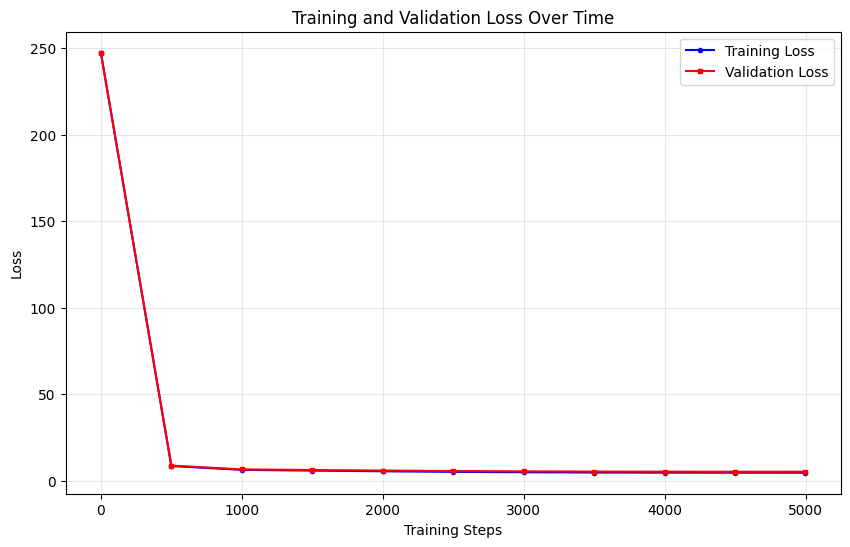

In [21]:
# Plot the losses
plt.figure(figsize=(10, 6))
plt.plot(eval_steps, train_losses, label='Training Loss', color='blue', marker='o', markersize=3)
plt.plot(eval_steps, val_losses, label='Validation Loss', color='red', marker='s', markersize=3)
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
def generate_text(model, tokenizer, prompt="", max_new_tokens=500, temperature=0.8, top_k=40):
    if prompt:
        # Encode the prompt
        encoded = encode(prompt, tokenizer)
        context = torch.tensor([encoded], dtype=torch.long, device=device)
    else:
        # Start with a more meaningful context than zeros
        context = torch.tensor([[tokenizer.token_to_id("[BOS]")]], dtype=torch.long, device=device)

    with torch.no_grad():
        generated_ids = model.generate(
            context,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_k=top_k
        )[0].tolist()

    return decode(generated_ids, tokenizer)

In [23]:
tokenizer = initialize_tokenizer()
prompts = ["Antonio:", "To be, or not to be,", "O Romeo, Romeo! wherefore art thou Romeo?"]

for prompt in prompts:
    print(f"\n=== Prompt: '{prompt}' ===")
    for temp in [1]:
        text = generate_text(
            model,
            tokenizer,
            prompt=prompt,
            temperature=temp,
            top_k=40,
            max_new_tokens=200
        )
        print(f"Temp {temp}: {text}\n")


=== Prompt: 'Antonio:' ===
Temp 1: Antonio : Which t ree and the s that to us . The T EN VOLIO . [ _Exit . _ ] If . _ ] He is not a g und ay , I think to him as we will . B ORA CHIO CHIO . Where should I could take this ? B EN VOLIO . And I ’ s the , or a thing , and this day . H al as the Duke of all that would have a , like to see the do this , And it is a . If not come to our de test of S LEN DER I do , And let a n ak en vo st thou may be of the first I cannot think The ro d it . ’ s . What shall speak this is that he he is a c ket of my head and his g ion ; For . This is per d , and thou hast I should not so . [ _Aside_ .] Thou co ck . _ ] [ _Exeunt . All - p ir on the Duke . Enter Duke H ot . A . _ ] Com inius .


=== Prompt: 'To be, or not to be,' ===
Temp 1: To be , or not to be , the re ly be me see our way . KING HENRY . [ _To E ly , a , good heart that I am a b ag t as that , which the best with the c itizen s , That so well - enter . _ Peace , he was be not , for an ion . A

In [ ]:
import torch, random
from collections import Counter

# Reuse tokenizer and load full corpus
tokenizer = initialize_tokenizer()

with open("input.txt", "r", encoding="utf-8") as f:
    corpus_text = f.read()

corpus_ids = torch.tensor(encode(corpus_text, tokenizer), dtype=torch.long)

def generate_token_ids(
    n_samples=32,
    max_new_tokens=200,
    prompt="",
    temperature=1.0,
    top_k=40,
):
    all_ids = []
    for _ in range(n_samples):
        text = generate_text(
            model,
            tokenizer,
            prompt=prompt,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_k=top_k,
        )
        all_ids.extend(encode(text, tokenizer))
    return torch.tensor(all_ids, dtype=torch.long)

# Example: generate a pool of model text once and reuse for metrics
gen_ids = generate_token_ids(
    n_samples=32,
    max_new_tokens=200,
    prompt="Antonio:", 
    temperature=1.0,
    top_k=40,
)
print(f"Generated {len(gen_ids)} tokens for evaluation.")


Generated 6464 tokens for evaluation.


In [25]:
def distinct_n(ids_tensor, n=1):
    ids = ids_tensor.tolist()
    if len(ids) < n:
        return 0.0
    ngrams = [tuple(ids[i:i+n]) for i in range(len(ids) - n + 1)]
    return len(set(ngrams)) / len(ngrams)

d1 = distinct_n(gen_ids, n=1)
d2 = distinct_n(gen_ids, n=2)

print(f"Distinct-1 (token diversity): {d1:.4f}")
print(f"Distinct-2 (bigram diversity): {d2:.4f}")


Distinct-1 (token diversity): 0.1101
Distinct-2 (bigram diversity): 0.5177


In [26]:
def ngram_set(ids_tensor, n):
    ids = ids_tensor.tolist()
    if len(ids) < n:
        return set()
    return set(tuple(ids[i:i+n]) for i in range(len(ids) - n + 1))

def ngram_overlap_stats(corpus_ids, gen_ids, n):
    corpus_ngrams = ngram_set(corpus_ids, n)
    gen_ngrams = ngram_set(gen_ids, n)

    if not corpus_ngrams or not gen_ngrams:
        return {
            "precision": 0.0,
            "recall": 0.0,
            "f1": 0.0,
            "novel_ratio": 0.0,
        }

    overlap = corpus_ngrams & gen_ngrams
    overlap_count = len(overlap)

    precision = overlap_count / len(gen_ngrams)          # how many gen n-grams exist in corpus
    recall = overlap_count / len(corpus_ngrams)         # how much of corpus n-grams we covered
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    novel_ratio = 1.0 - precision                       # fraction of gen n-grams NOT seen in corpus

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "novel_ratio": novel_ratio,
        "gen_total": len(gen_ngrams),
        "corpus_total": len(corpus_ngrams),
        "overlap_count": overlap_count,
    }

for n in [2, 3]:
    stats = ngram_overlap_stats(corpus_ids, gen_ids, n)
    print(f"\n=== {n}-gram overlap ===")
    print(f"Precision:   {stats['precision']:.4f}")
    print(f"Recall:      {stats['recall']:.4f}")
    print(f"F1:          {stats['f1']:.4f}")
    print(f"Novel ratio: {stats['novel_ratio']:.4f}")
    print(f"Generated {n}-grams: {stats['gen_total']}")
    print(f"Corpus {n}-grams:    {stats['corpus_total']}")
    print(f"Overlap count:       {stats['overlap_count']}")



=== 2-gram overlap ===
Precision:   0.9453
Recall:      0.0130
F1:          0.0257
Novel ratio: 0.0547
Generated 2-grams: 3346
Corpus 2-grams:    242503
Overlap count:       3163

=== 3-gram overlap ===
Precision:   0.5581
Recall:      0.0036
F1:          0.0071
Novel ratio: 0.4419
Generated 3-grams: 5678
Corpus 3-grams:    882875
Overlap count:       3169


In [ ]:
!python -m pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer
import torch, re

embed_device = device if torch.cuda.is_available() else "cpu"
style_model = SentenceTransformer("all-MiniLM-L6-v2", device=embed_device)

def segment_text_into_spans(text, max_len=120, min_len=10):
    # First, split on sentence-ish punctuation
    raw_spans = re.split(r'[.!?;:]', text)
    spans = []

    for span in raw_spans:
        span = span.strip()
        if len(span) < min_len:
            continue

        # If span is too long, chunk it into max_len pieces
        while len(span) > max_len:
            cut = span[:max_len]
            spans.append(cut.strip())
            span = span[max_len:].strip()

        if len(span) >= min_len:
            spans.append(span)

    return spans

def sample_spans(spans, n=200):
    if len(spans) == 0:
        return []
    if len(spans) <= n:
        return spans
    return random.sample(spans, n)

# 1) Real Shakespeare spans from corpus_text
real_spans_all = segment_text_into_spans(corpus_text, max_len=120, min_len=10)
real_spans = sample_spans(real_spans_all, n=200)

# 2) Generated text from the model
gen_big_text = generate_text(
    model,
    tokenizer,
    prompt="Enter Hamlet and Horatio.",
    max_new_tokens=3000,
    temperature=1.0,
    top_k=40,
)

gen_spans_all = segment_text_into_spans(gen_big_text, max_len=120, min_len=10)
gen_spans = sample_spans(gen_spans_all, n=200)

print(f"Real spans: {len(real_spans)}, Generated spans: {len(gen_spans)}")

if len(real_spans) > 0 and len(gen_spans) > 0:
    with torch.no_grad():
        real_emb = style_model.encode(
            real_spans,
            convert_to_tensor=True,
            device=embed_device,
            show_progress_bar=False
        )
        gen_emb = style_model.encode(
            gen_spans,
            convert_to_tensor=True,
            device=embed_device,
            show_progress_bar=False
        )

    # cosine similarity matrix
    sim_matrix = torch.matmul(gen_emb, real_emb.T)  # (G, R)
    best_sim, _ = torch.max(sim_matrix, dim=1)      # best match per generated span
    avg_best_sim = best_sim.mean().item()

    print(f"\nAverage best cosine similarity (generated → closest real span): {avg_best_sim:.4f}")
else:
    print("Not enough spans to compute style similarity.")


'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x00000185638982D0>: Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: da50baaf-ee2d-4b33-9ec4-b2f503df050c)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/./modules.json
Retrying in 1s [Retry 1/5].


Real spans: 200, Generated spans: 200

Average best cosine similarity (generated → closest real span): 0.4201


In [28]:
torch.save(model.state_dict(), "mini_transformer_shakespeare.pt")